<a href="https://colab.research.google.com/github/saiashwinkumar/DBA5103-term-paper/blob/main/ORA_consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1 (Greedy Approach)

In [ ]:
import csv
from collections import defaultdict, deque, Counter

# ==========================================
# PART 1: OPTIMIZATION ALGORITHM (OPTIMIZER)
# ==========================================
def solve_weighted_greedy(input_data):
    """
    Generate a traffic light schedule based on traffic density.
    Input: Parsed data (streets, paths, I, D...)
    Output: Schedule dictionary {intersection_id: [(street_name, duration), ...]}
    """
    D, F, I, streets, paths = input_data

    # 1. Count traffic on each street
    street_counts = Counter()
    for path in paths:
        for street in path:
            street_counts[street] += 1

    # 2. Group streets by their ending intersection
    intersection_incoming = defaultdict(list)
    for name, info in streets.items():
        # info = (start, end, length)
        end_node = info[1]
        intersection_incoming[end_node].append(name)

    # 3. Build the schedule
    schedule = {}
    for i in range(I):
        incoming = intersection_incoming[i]

        # Remove streets that have no cars
        active_streets = [s for s in incoming if street_counts[s] > 0]

        if not active_streets:
            continue

        # Sort by descending traffic (most cars first)
        active_streets.sort(key=lambda s: street_counts[s], reverse=True)

        # Assign durations (Heuristic: more cars → more time, capped at 2s)
        min_cars = street_counts[active_streets[-1]]

        cycle = []
        for s in active_streets:
            cnt = street_counts[s]
            # If > 10× the lowest count → 2 seconds, else 1 second
            duration = 2 if cnt > min_cars * 10 else 1
            cycle.append((s, duration))

        schedule[i] = cycle

    return schedule

# ==========================================
# PART 2: SIMULATOR & SCORER
# ==========================================
def run_simulation(input_data, schedule):
    """
    Simulate vehicle movement second-by-second to calculate the score.
    """
    D, F, I, streets, paths = input_data

    # --- Data structures for simulation ---

    # 1. Car states
    # car_state[car_id] = (current_street_idx_in_path, arrival_time_at_street_end)
    # Initially, all cars start waiting at the end of the first street (idx = 0) at t=0.
    car_states = []
    for i in range(len(paths)):
        car_states.append({'idx': 0, 'arrive_time': 0})

    # 2. Queues for each street (FIFO)
    queues = defaultdict(deque)

    # Put each car into the queue of its starting street
    for car_id, path in enumerate(paths):
        start_street = path[0]
        queues[start_street].append(car_id)

    # 3. Pre-compute traffic light cycles
    inter_configs = {}
    for i, cycles in schedule.items():
        green_list = []
        for name, duration in cycles:
            green_list.extend([name] * duration)
        if green_list:
            inter_configs[i] = {
                'cycle_len': len(green_list),
                'sequence': green_list
            }

    # --- Time simulation loop (0 → D) ---
    total_score = 0
    cars_finished = 0

    # cars_waiting_to_move[t] = list of cars that finish a street and will join the next queue at time t
    future_arrivals = defaultdict(list)

    for t in range(D + 1):
        # A. Update cars arriving at the end of streets (scheduled earlier)
        if t in future_arrivals:
            for car_id, street_name in future_arrivals[t]:
                queues[street_name].append(car_id)
            del future_arrivals[t]  # Free memory

        # B. Process intersections (cars passing green lights)
        for i in range(I):
            if i not in inter_configs:
                continue

            config = inter_configs[i]

            # Determine which street has green light at time t
            t_mod = t % config['cycle_len']
            green_street = config['sequence'][t_mod]

            # Check if any car is waiting on this street
            if queues[green_street]:
                car_id = queues[green_street].popleft()

                # Car info
                car = car_states[car_id]
                path = paths[car_id]

                # Car has completed the current street (path[car['idx']])
                # Check if this is the last street
                if car['idx'] == len(path) - 1:
                    # Score = F + (D - t)
                    points = F + (D - t)
                    total_score += points
                    cars_finished += 1
                else:
                    # Move to the next street
                    next_street_name = path[car['idx'] + 1]
                    travel_time = streets[next_street_name][2]  # L

                    # Update car state
                    car['idx'] += 1
                    arrival_time = t + travel_time

                    if arrival_time <= D:
                        future_arrivals[arrival_time].append((car_id, next_street_name))

    return total_score, cars_finished

# ==========================================
# MAIN DRIVER
# ==========================================
def main():
    input_file = 'hashcode.csv'
    output_file = 'submission_scored.txt'

    print("--- Starting process ---")

    with open(input_file, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)

    # Parse header
    D, I, S, V, F = map(int, rows[0])

    # Parse streets
    # Format: start, end, name, L
    streets = {}  # name -> (start, end, L)
    idx = 1
    for _ in range(S):
        row = rows[idx]
        streets[row[2]] = (int(row[0]), int(row[1]), int(row[3]))
        idx += 1

    # Parse paths
    # Format: P, name1, name2...
    paths = []
    for _ in range(V):
        paths.append(rows[idx][1:])
        idx += 1

    input_data = (D, F, I, streets, paths)
    print(f"Data loaded: {I} intersections, {S} streets, {V} cars.")

    # 2. Run optimizer
    print("Running optimization algorithm...")
    schedule = solve_weighted_greedy(input_data)

    # 3. Write output file (HashCode format)
    with open(output_file, 'w') as f:
        f.write(f"{len(schedule)}\n")
        for i, cycle in schedule.items():
            f.write(f"{i}\n")
            f.write(f"{len(cycle)}\n")
            for name, duration in cycle:
                f.write(f"{name} {duration}\n")
    print(f"Submission written to: {output_file}")

    # 4. Run simulation to compute score
    print("Running simulation for scoring...")
    score, finished_count = run_simulation(input_data, schedule)

    print("-" * 30)
    print("SIMULATION RESULTS:")
    print(f"Cars finished: {finished_count} / {V}")
    print(f"TOTAL SCORE: {score}")
    print("-" * 30)

if __name__ == "__main__":
    main()


# Model 2 (Mixed-Integer Programming)

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import collections
import math

# --- Data Structures and Input Parsing ---

def parse_input(filename):
    """
    Parses the traffic simulation input file.
    """
    data = {}
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 1. First line: D, I, S, V, F
    D, I, S, V, F = map(int, lines[0].split())
    data['D'] = D  # Simulation duration
    data['I'] = I  # Number of intersections (0 to I-1)
    data['S'] = S  # Number of streets
    data['V'] = V  # Number of cars
    data['F'] = F  # Bonus points

    # 2. Street descriptions (S lines)
    streets_data = {}
    lines_idx = 1
    for i in range(S):
        parts = lines[lines_idx].split()
        B = int(parts[0])  # Start intersection
        E = int(parts[1])  # End intersection
        name = parts[2]     # Street name
        L = int(parts[3])  # Length/Time

        streets_data[name] = {
            'B': B, 'E': E, 'L': L, 'name': name
        }
        lines_idx += 1
    data['streets'] = streets_data

    # 3. Car paths (V lines)
    cars_data = []
    for i in range(V):
        parts = lines[lines_idx].split()
        P = int(parts[0])  # Path length
        path = parts[1:P+1]
        cars_data.append({
            'P': P, 'path': path
        })
        lines_idx += 1
    data['cars'] = cars_data

    return data

def calculate_demand(data):
    """
    Calculates the total number of cars that use each street, representing the demand.
    This demand drives the Gurobi optimization model.
    """
    street_demand = collections.defaultdict(int)

    # Iterate over all cars
    for car in data['cars']:
        # Cars use all streets in their path *except* the last one (they don't queue there)
        path_for_queuing = car['path'][:-1]
        for street_name in path_for_queuing:
            street_demand[street_name] += 1

    return street_demand

# --- Gurobi Optimization Model (Heuristic Assignment) ---

def optimize_schedule_durations(data, street_demand):
    """
    Uses Gurobi to assign a minimum green light duration (t_s) to streets
    that have high car demand (D_s).

    This is a simplification (a linear program) because the true dynamic
    queuing and cycle time relationship is non-linear and non-convex.

    Objective: Minimize the total green time assigned.
    Constraint: Green time must be at least 1, and for high-demand streets,
                it must be proportional to the demand.
    """

    # 1. Pre-process street data for optimization
    streets = list(data['streets'].keys())

    # Maximum demand value for normalization
    max_demand = max(street_demand.values()) if street_demand else 1
    # Big M value (max duration is D, but let's use a safe upper bound)
    D_max = data['D']

    print("Building Gurobi model...")
    m = gp.Model("TrafficScheduleHeuristic")
    m.setParam('OutputFlag', 0) # Suppress Gurobi output

    # 2. Variables
    # t_s: Integer, green light duration for street s.
    t = m.addVars(streets, vtype=GRB.INTEGER, name="GreenTime", lb=0)
    # x_s: Binary, 1 if street s is included in the schedule, 0 otherwise.
    x = m.addVars(streets, vtype=GRB.BINARY, name="Scheduled")

    # 3. Objective: Minimize total green time used (proxy for minimizing cycle length)
    m.setObjective(t.sum(), GRB.MINIMIZE)

    # 4. Constraints
    for s in streets:
        demand = street_demand[s]

        # Constraint 1: Big M linkage - If t_s > 0, then x_s must be 1.
        m.addConstr(t[s] <= D_max * x[s], f"BigM_Upper_{s}")

        # Constraint 2: If street is scheduled (x_s=1), min green time is 1.
        m.addConstr(t[s] >= x[s], f"MinTime_Lower_{s}")

        # Constraint 3: Demand-based Heuristic Assignment (Tune this factor!)
        # Streets with demand must be scheduled (x_s=1)
        if demand > 0:
            m.addConstr(x[s] == 1, f"MustSchedule_{s}")

            # Heuristic: Green time is proportional to demand, ensuring at least 1.
            # Factor of 10 is an arbitrary tuning parameter: D_s/10
            # Higher factor = shorter green lights, tighter cycles, but higher queue risk.
            required_time = max(1, math.ceil(demand / 10))
            m.addConstr(t[s] >= required_time, f"DemandProp_{s}")

    # 5. Solve the model
    m.optimize()

    # 6. Extract the solution
    schedule_durations = {}
    if m.status == GRB.OPTIMAL:
        for s in streets:
            duration = int(t[s].X)
            if duration > 0:
                schedule_durations[s] = duration

    return schedule_durations

# --- Solution Formatting ---

def create_submission_file(data, schedule_durations):
    """
    Formats the Gurobi solution into the required submission file format.
    The order of streets in the schedule is a secondary heuristic (e.g., alternating
    based on a simple rule, but here we'll just use the order of appearance).
    """

    # 1. Group streets by the intersection they lead into
    intersection_schedules = collections.defaultdict(list)
    for s_name, duration in schedule_durations.items():
        street = data['streets'][s_name]
        # Street leads *into* intersection E
        intersection_id = street['E']

        # Only include streets with a positive duration assigned by Gurobi
        if duration > 0:
            intersection_schedules[intersection_id].append((s_name, duration))

    # 2. Build the output content
    output_lines = []

    # A: Number of intersections with a schedule
    output_lines.append(f"{len(intersection_schedules)}")

    for i_id, schedules in intersection_schedules.items():
        # i: Intersection ID
        output_lines.append(f"{i_id}")

        # E_i: Number of incoming streets covered
        output_lines.append(f"{len(schedules)}")

        # E_i lines: street name and duration T
        for s_name, duration in schedules:
            output_lines.append(f"{s_name} {duration}")

    return "\n".join(output_lines)


# --- Main Execution ---

def main(input_filename="hashcode.in.txt", output_filename="submission.txt"):
    try:
        # 1. Parse Input
        print(f"Reading input from {input_filename}...")
        data = parse_input(input_filename)

        # 2. Calculate Demand (Input for Gurobi)
        street_demand = calculate_demand(data)

        # 3. Optimize Schedule Durations using Gurobi
        schedule_durations = optimize_schedule_durations(data, street_demand)

        # 4. Format Output
        submission_content = create_submission_file(data, schedule_durations)

        # 5. Write to File
        with open(output_filename, 'w') as f:
            f.write(submission_content)

        print(f"Optimization complete. Schedule written to {output_filename}.")
        print("\n--- Generated Submission File Content ---\n")
        # Print only the first 20 lines to avoid overwhelming the output for large files
        print('\n'.join(submission_content.splitlines()[:20]))
        if len(submission_content.splitlines()) > 20:
             print("[... Submission truncated for brevity ...]")
        print("\n-----------------------------------------\n")

    except FileNotFoundError:
        print(f"Error: Input file '{input_filename}' not found. Please ensure it exists.")

if __name__ == '__main__':
    # You must have Gurobi installed and licensed to run this.
    main()

In [ ]:
import collections
import math
import sys
import gurobipy as gp
from gurobipy import GRB

# Increase recursion limit for deep dictionary/list copies in large datasets
sys.setrecursionlimit(2000)

# --- GLOBAL DATA STRUCTURES ---
# D: Simulation Duration, F: Bonus
D, F = 0, 0
STREETS = {}
CARS_DATA = []
INTERSECTIONS = {}

# --- HELPER CLASSES ---

class Car:
    """Represents a single car's state in the simulation."""
    def __init__(self, car_id, path):
        self.id = car_id
        self.path = path  # List of street names to follow
        self.path_index = 0
        self.current_street_name = path[0]
        self.current_street_length = STREETS[path[0]]['L']

        # Position on the current street: 0 is at the start (just entered the street),
        # Length L is at the end (waiting at the light).
        self.position = 0

        # State: 'MOVING', 'WAITING', 'FINISHED', 'IDLE' (before starting)
        self.status = 'IDLE'
        self.start_time = 0
        self.finish_time = -1

    def get_destination_intersection(self):
        """Returns the ID of the intersection at the end of the current street."""
        if self.path_index < len(self.path):
            return STREETS[self.current_street_name]['E']
        return -1 # Finished

    def move(self):
        """Advances the car one unit (one second)."""
        if self.status == 'MOVING':
            self.position += 1

    def next_street(self, current_time):
        """Moves the car to the next street in its path."""
        self.path_index += 1

        # Check if the path is complete
        if self.path_index >= len(self.path):
            self.status = 'FINISHED'
            self.finish_time = current_time
            return

        # Move to the new street
        self.current_street_name = self.path[self.path_index]
        self.current_street_length = STREETS[self.current_street_name]['L']
        self.position = 1 # Car immediately moves 1 unit into the new street
        self.status = 'MOVING'

    def wait(self):
        """Sets the car's status to WAITING (at the end of a street)."""
        self.status = 'WAITING'

class Intersection:
    """Represents a single intersection with its traffic light schedule."""
    def __init__(self, i_id):
        self.id = i_id
        # {street_name: [T, start_time, end_time]}
        self.schedule = []
        self.queues = collections.defaultdict(collections.deque) # {street_name: deque([Car_1, Car_2, ...])}
        self.cycle_time = 0
        self.current_green_street = None
        self.time_in_cycle = 0 # Current time modulo cycle_time

    def set_schedule(self, schedule_list):
        """Loads the schedule from the submission file."""
        self.schedule = schedule_list
        self.cycle_time = sum(duration for _, duration in schedule_list)

    def update_light(self, current_time):
        """Determines which street is green at the current time T."""
        if self.cycle_time == 0 or not self.schedule:
            self.current_green_street = None
            return

        # Calculate time within the cycle
        self.time_in_cycle = current_time % self.cycle_time

        # Find the currently green street
        cumulative_time = 0
        for street_name, duration in self.schedule:
            if self.time_in_cycle >= cumulative_time and self.time_in_cycle < cumulative_time + duration:
                self.current_green_street = street_name
                return
            cumulative_time += duration

        # Should not happen if logic is correct, but default to None
        self.current_green_street = None

# --- INITIALIZATION AND PARSING ---

def parse_input(filename):
    """Parses the traffic simulation input file and initializes global data."""
    global D, F, STREETS, CARS_DATA, INTERSECTIONS

    with open(filename, 'r') as f:
        lines = f.readlines()

    # 1. First line: D, I, S, V, F
    D, I, S, V, F = map(int, lines[0].split())

    # Initialize all intersections
    for i in range(I):
        INTERSECTIONS[i] = Intersection(i)

    # 2. Street descriptions (S lines)
    lines_idx = 1
    for i in range(S):
        B, E, name, L = lines[lines_idx].split()
        B, E, L = int(B), int(E), int(L)
        STREETS[name] = {'B': B, 'E': E, 'L': L, 'name': name}
        lines_idx += 1

    # 3. Car paths (V lines)
    for i in range(V):
        parts = lines[lines_idx].split()
        path = parts[1:]
        CARS_DATA.append(Car(i, path))
        lines_idx += 1

    # Set the initial status for cars that can start moving
    for car in CARS_DATA:
        if car.current_street_length == 0:
            # Handle the highly unlikely case of 0-length streets (instant travel)
            # This car effectively starts at the end of its first street.
            car.position = 0 # It will move to the next street immediately
        else:
            car.status = 'MOVING' # All cars start moving on their first street

    print(f"Data Loaded. D={D}, F={F}, Streets={len(STREETS)}, Cars={len(CARS_DATA)}, Intersections={len(INTERSECTIONS)}")

def parse_submission(filename):
    """Loads the schedule from the submission file."""
    try:
        with open(filename, 'r') as f:
            lines = f.read().splitlines()
    except FileNotFoundError:
        print(f"Error: Submission file '{filename}' not found.")
        return

    if not lines: return

    A = int(lines[0]) # Number of scheduled intersections
    line_idx = 1

    for _ in range(A):
        i_id = int(lines[line_idx])
        line_idx += 1
        E_i = int(lines[line_idx])
        line_idx += 1

        schedule = []
        for _ in range(E_i):
            street_name, duration = lines[line_idx].split()
            schedule.append((street_name, int(duration)))
            line_idx += 1

        if i_id in INTERSECTIONS:
            INTERSECTIONS[i_id].set_schedule(schedule)

    print(f"Schedule Loaded. {A} intersections have defined cycles.")

# --- SIMULATION LOGIC ---

def run_simulation():
    """Runs the second-by-second simulation and calculates the score."""
    global D

    # Initialize total score
    total_score = 0

    # 1. Initial Car Setup (Car must move its initial street first)
    # Cars starting on a street of length L, take L seconds to reach the first light.

    for t in range(1, D + 1):

        # --- A. Update Traffic Lights ---
        # Update the green street for all intersections based on the current time t
        for i_id, intersection in INTERSECTIONS.items():
            intersection.update_light(t)

        # --- B. Process Cars at Lights (Green Light Action) ---
        # Determine which cars get to pass the light this second.

        cars_to_move_from_queue = [] # List to track cars that pass the light

        for i_id, intersection in INTERSECTIONS.items():
            green_street = intersection.current_green_street

            if green_street and intersection.queues[green_street]:
                # If the green street has waiting cars, the first car passes
                car = intersection.queues[green_street].popleft()
                cars_to_move_from_queue.append(car)

        # Now, move the cars that passed the light
        for car in cars_to_move_from_queue:
             car.next_street(t) # Moves car into the next street (pos=1, status=MOVING)


        # --- C. Move All Moving Cars ---
        # Advance every MOVING car one step (1 second)

        cars_to_queue_next_step = [] # Cars that reach the end of their street

        for car in CARS_DATA:
            if car.status == 'MOVING':
                car.move()

                # Check if the car reached the end of its current street
                if car.position >= car.current_street_length:

                    if car.path_index == len(car.path) - 1:
                        # Reached the end of the final street
                        car.status = 'FINISHED'
                        car.finish_time = t
                        total_score += F + (D - car.finish_time)
                    else:
                        # Reached the end of a non-final street, now waiting at the light
                        car.position = car.current_street_length # Normalize position to the end
                        car.wait()
                        cars_to_queue_next_step.append(car)

        # --- D. Enqueue Waiting Cars ---
        # Cars that just arrived at a light need to be placed in the queue
        for car in cars_to_queue_next_step:
            dest_i = car.get_destination_intersection()
            if dest_i != -1: # Ensure it's a valid intersection
                street_name = car.current_street_name
                INTERSECTIONS[dest_i].queues[street_name].append(car)


        # --- E. Progress Report ---
        if t % 500 == 0:
            finished_count = sum(1 for car in CARS_DATA if car.status == 'FINISHED')
            print(f"Time T={t}/{D}. Finished Cars: {finished_count}. Current Score: {total_score}")

    # --- F. Final Score Tally (Final check for score) ---
    # The score formula includes the check T_finish <= D, which is handled implicitly by the loop structure.

    return total_score

# --- Main Execution ---

def main():
    global D, F
    input_filename = "hashcode.in.txt"
    submission_filename = "submission.txt"

    # 1. Load Data
    try:
        parse_input(input_filename)
        parse_submission(submission_filename)
    except FileNotFoundError as e:
        print(f"CRITICAL ERROR: {e}. Ensure both '{input_filename}' and '{submission_filename}' are available.")
        return

    # 2. Run Simulation
    print("\n--- Starting Simulation ---")
    final_score = run_simulation()

    # 3. Print Results
    print("\n==============================================")
    print(f"SIMULATION COMPLETE at T={D}")
    print(f"FINAL TOTAL SCORE: {final_score}")
    print(f"Total Cars: {len(CARS_DATA)}")
    print(f"Cars Finished: {sum(1 for car in CARS_DATA if car.status == 'FINISHED')}")
    print("==============================================")


if __name__ == '__main__':
    main()

# Model 3 (Demand-Weighted Local Search)

In [ ]:
import sys
from collections import defaultdict
from bisect import bisect_right

# ============================================================
# Data structures
# ============================================================

class Street:
    def __init__(self, unique_id, start, end, name, length):
        self.unique_id = unique_id
        self.start = start
        self.end = end
        self.name = name
        self.length = length
        self.incoming_usage_count = 0
        self.cars_on_start = 0


class Car:
    def __init__(self, unique_id, streets):
        self.unique_id = unique_id
        self.streets = streets  # list[Street]

    def time_need_to_drive(self):
        # sum of lengths from street index 1 onwards
        # (i.e., total travel after reaching first intersection)
        t = 0
        for i in range(1, len(self.streets)):
            t += self.streets[i].length
        return t


class Intersection:
    def __init__(self, idx):
        self.id = idx
        self.incoming = []  # list[Street]
        self.outgoing = []  # list[Street]


class CarSimulationPosition:
    """
    Stores precomputed arrays of:
      - street ids
      - street end intersections
      - street lengths
    """
    def __init__(self, car, time_got_here):
        self.car = car
        self.street_number = 0
        self.time_got_here = time_got_here
        self.time_left_on_drive = car.time_need_to_drive()

        self.street_ids = []
        self.street_ends = []
        self.street_lengths = []

        for st in self.car.streets:
            self.street_ids.append(st.unique_id)
            self.street_ends.append(st.end)
            self.street_lengths.append(st.length)

    def init(self, time_got_here):
        """Reset for a new simulation run."""
        self.street_number = 0
        self.time_got_here = time_got_here
        self.time_left_on_drive = self.car.time_need_to_drive()


class Problem:
    def __init__(self):
        self.duration = 0
        self.bonus_per_car = 0
        self.intersections = []  # list[Intersection]
        self.streets = []        # list[Street]
        self.cars = []           # list[Car]

    @staticmethod
    def load_problem(file_name):
        """
        Hash Code 2021 input format.
        """
        with open(file_name, "r") as f:
            first = f.readline().split()
            d = int(first[0])
            number_of_intersections = int(first[1])
            s = int(first[2])
            v = int(first[3])
            f_bonus = int(first[4])

            problem = Problem()
            problem.duration = d
            problem.bonus_per_car = f_bonus

            # Read streets
            streets_map = {}
            for street_id in range(s):
                line = f.readline().split()
                start = int(line[0])
                end = int(line[1])
                name = line[2]
                length = int(line[3])
                st = Street(street_id, start, end, name, length)
                problem.streets.append(st)
                streets_map[name] = st

            # Read cars
            for car_id in range(v):
                parts = f.readline().split()
                p = int(parts[0])
                street_names = parts[1:]
                car_streets = [streets_map[name] for name in street_names]
                problem.cars.append(Car(car_id, car_streets))

        # Build intersections
        problem.intersections = [Intersection(i) for i in range(number_of_intersections)]
        for st in problem.streets:
            problem.intersections[st.start].outgoing.append(st)
            problem.intersections[st.end].incoming.append(st)

        # Count incoming usage (for completeness)
        for car in problem.cars:
            for i in range(len(car.streets) - 1):
                car.streets[i].incoming_usage_count += 1

        # Cars on start
        for st in problem.streets:
            st.cars_on_start = 0
        for car in problem.cars:
            car.streets[0].cars_on_start += 1

        return problem

    def remove_unused_streets(self):
        """
        remove incoming streets from intersection
        if their IncomingUsageCount == 0.
        """
        removed = 0
        for inter in self.intersections:
            keep = []
            for st in inter.incoming:
                if st.incoming_usage_count > 0:
                    keep.append(st)
                else:
                    removed += 1
            inter.incoming = keep
        return removed


class GreenLightCycle:
    def __init__(self, street, duration):
        self.street = street        # Street object
        self.duration = duration    # int
        # 'GreenLightUsed' is only used in the fancy optimizeGreenLightOrder4,
        # not in the lite simulation, so we skip it here.


class SolutionIntersection:
    def __init__(self, idx):
        self.id = idx
        self.green_cycles = []      # list[GreenLightCycle]
        self.green_array = []       # list[street_id] (expanded cycle)
        self.last_car_pass_time = -1

    def build_green_array(self):
        """
        Flatten cycles into an array where index t % len(green_array)
        tells which street_id is green at that time.
        """
        self.green_array = []
        for cycle in self.green_cycles:
            for _ in range(cycle.duration):
                self.green_array.append(cycle.street.unique_id)


class Solution:
    def __init__(self, num_intersections):
        self.intersections = [SolutionIntersection(i) for i in range(num_intersections)]

    def count_intersections_with_green_lights(self):
        c = 0
        for si in self.intersections:
            if any(cyc.duration > 0 for cyc in si.green_cycles):
                c += 1
        return c


# ============================================================
# Basic initial solution: 1 second per incoming street
# ============================================================

def init_basic_solution(problem, solution):
    """
    - For each intersection i:
      - one GreenLightCycle per incoming street, duration=1
    """
    for inter in problem.intersections:
        si = solution.intersections[inter.id]
        si.green_cycles.clear()
        for st in inter.incoming:
            si.green_cycles.append(GreenLightCycle(street=st, duration=1))
import math
from collections import defaultdict

def build_weighted_solution(problem):
    """
    Build a better-than-naive initial schedule:
    - Give more green seconds to streets with more "finishable" cars.
    - Keep one cycle per intersection.
    """
    D = problem.duration
    bonus = problem.bonus_per_car

    solution = Solution(num_intersections=len(problem.intersections))

    # 1) Find finishable cars and count usage per street
    street_weight = defaultdict(float)

    for car in problem.cars:
        total_time = car.time_need_to_drive()
        if total_time > D:
            continue  # this car can never finish, ignore

        # weight of this car could be 1, or (D - total_time) to favor quick paths
        w = 1.0
        # or try: w = 1.0 + (D - total_time) / D

        for i in range(len(car.streets) - 1):  # only internal streets
            st = car.streets[i]
            street_weight[st.unique_id] += w

    # 2) For each intersection, distribute green time among its incoming streets
    for inter in problem.intersections:
        si = solution.intersections[inter.id]
        incoming = inter.incoming

        if not incoming:
            continue

        # Get weights for incoming streets, fallback to 0
        weights = [street_weight[st.unique_id] for st in incoming]
        total_w = sum(weights)

        if total_w == 0:
            # No meaningful weight info -> fallback to uniform 1s
            for st in incoming:
                si.green_cycles.append(GreenLightCycle(street=st, duration=1))
            continue

        # Choose total cycle length (small-ish to react quickly)
        # try between 4 and 10
        TOTAL_CYCLE = min(10, max(3, len(incoming)))

        # duration_i = max(1, round(TOTAL_CYCLE * w_i / total_w))
        durations = []
        for w in weights:
            dur = max(1, int(round(TOTAL_CYCLE * w / total_w)))
            durations.append(dur)

        # If rounding overshot the total, trim a bit
        extra = sum(durations) - TOTAL_CYCLE
        while extra > 0 and any(d > 1 for d in durations):
            for idx, d in enumerate(durations):
                if extra == 0:
                    break
                if d > 1:
                    durations[idx] -= 1
                    extra -= 1

        # Add cycles (we can also sort by weight desc)
        order = sorted(range(len(incoming)), key=lambda idx: -weights[idx])
        for idx in order:
            st = incoming[idx]
            dur = durations[idx]
            si.green_cycles.append(GreenLightCycle(street=st, duration=dur))

    return solution

import random
import copy

def clone_solution(solution):
    new_sol = Solution(len(solution.intersections))
    for i, si in enumerate(solution.intersections):
        new_si = new_sol.intersections[i]
        for cyc in si.green_cycles:
            new_si.green_cycles.append(
                GreenLightCycle(cyc.street, cyc.duration)
            )
    return new_sol

def local_search(problem, initial_solution, iters=1000, print_every=100):
    """
    Simple hill-climbing:
    - Start from initial_solution
    - Randomly tweak intersection schedules
    - Keep modifications that improve score
    """
    best_solution = clone_solution(initial_solution)
    best_score = run_simulation_lite(problem, best_solution)
    print(f"Initial score: {best_score}")

    for it in range(1, iters + 1):
        # Work on a copy
        candidate = clone_solution(best_solution)

        # Pick a random intersection that has at least 1 green cycle
        idxs = [i for i, si in enumerate(candidate.intersections) if len(si.green_cycles) > 0]
        if not idxs:
            break
        i = random.choice(idxs)
        si = candidate.intersections[i]

        # Decide move type: 0 = swap order, 1 = change duration
        move_type = random.randint(0, 1)

        if move_type == 0 and len(si.green_cycles) >= 2:
            # Swap two random phases
            a, b = random.sample(range(len(si.green_cycles)), 2)
            si.green_cycles[a], si.green_cycles[b] = si.green_cycles[b], si.green_cycles[a]

        else:
            # Change duration of a random phase
            j = random.randrange(len(si.green_cycles))
            old_dur = si.green_cycles[j].duration
            if old_dur == 1:
                # either stay or increase
                si.green_cycles[j].duration = old_dur + 1
            else:
                # +/- 1 with 50-50
                if random.random() < 0.5:
                    si.green_cycles[j].duration = max(1, old_dur - 1)
                else:
                    si.green_cycles[j].duration = old_dur + 1

        # Evaluate candidate
        candidate_score = run_simulation_lite(problem, candidate)

        if candidate_score > best_score:
            best_solution = candidate
            best_score = candidate_score
            if print_every is not None:
                print(f"[iter {it}] Improved: {best_score}")

        if print_every and it % print_every == 0:
            print(f"[iter {it}] current best: {best_score}")

    return best_solution, best_score


# ============================================================
# Simulation (lite version)
# ============================================================

def run_simulation_lite_with_stats(problem, solution):
    """
    Discrete-time simulation from t=0..Problem.Duration.

    Returns:
        {
            "score": total_score,
            "finished_cars": number_of_cars_that_finished_in_time,
            "total_time_saved": sum_over_finished_cars_of(D - finish_time)
        }
    """
    D = problem.duration
    bonus = problem.bonus_per_car
    cars = problem.cars

    # Build expanded green arrays per intersection
    for si in solution.intersections:
        si.build_green_array()
        si.last_car_pass_time = -1

    # Prepare CarSimulationPosition instances, one per car
    car_positions = []
    n = len(cars)
    simulation_car_start = -(n + 1)  # start times negative so they are available at t=0
    for car in cars:
        cp = CarSimulationPosition(car, simulation_car_start)
        car_positions.append(cp)
        simulation_car_start += 1

    # Sort by TimeGotHere ascending
    car_positions.sort(key=lambda c: c.time_got_here)

    total_score = 0
    finished_cars = 0
    total_time_saved = 0
    current_time = 0

    while current_time <= D:
        i = 0
        # Iterate cars in order of arrival time
        while i < n:
            cp = car_positions[i]
            # If this car arrives in the future, all later cars do too
            if cp.time_got_here > current_time:
                break

            # Determine intersection where car is waiting:
            # It is at end of its "current" street index street_number
            inter_id = cp.street_ends[cp.street_number]
            si = solution.intersections[inter_id]

            # Check if this intersection already used this time step
            if si.last_car_pass_time == current_time:
                i += 1
                continue

            if len(si.green_array) == 0:
                i += 1
                continue

            # Which street id is green now?
            green_street_id = si.green_array[current_time % len(si.green_array)]

            # Is this car's incoming street the green one?
            if cp.street_ids[cp.street_number] != green_street_id:
                i += 1
                continue

            # Intersection is now used at this time step
            si.last_car_pass_time = current_time

            # Car passes intersection and enters the next street
            cp.street_number += 1
            new_len = cp.street_lengths[cp.street_number]
            cp.time_got_here = current_time + new_len
            cp.time_left_on_drive -= new_len

            # Check if car finished its route
            if cp.street_number == len(cp.car.streets) - 1:
                # If finished on time, award score and update stats
                if cp.time_got_here <= D:
                    time_saved = D - cp.time_got_here
                    total_score += bonus + time_saved
                    finished_cars += 1
                    total_time_saved += time_saved

                # Move finished car to the end (so it is never processed again)
                cp.time_got_here = D + 1  # put far in future
                car_positions.pop(i)
                car_positions.append(cp)
                # n unchanged; next car is now at index i, so do not increment
                continue
            else:
                # Car not finished; we must keep car_positions sorted by time_got_here.
                car_positions.pop(i)
                # Find new insertion index
                new_pos = bisect_right(
                    [c.time_got_here for c in car_positions],
                    cp.time_got_here
                )
                car_positions.insert(new_pos, cp)
                # Next car is now at index i, so do not increment
                continue

            # Default: go to next car
            i += 1

        current_time += 1

    return {
        "score": total_score,
        "finished_cars": finished_cars,
        "total_time_saved": total_time_saved,
    }


def run_simulation_lite(problem, solution):
    """
    Backwards-compatible wrapper used by local_search etc.
    Still returns only the score.
    """
    stats = run_simulation_lite_with_stats(problem, solution)
    return stats["score"]

# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    INPUT_FILE = "hashcode.txt"   # change to your path
    problem = Problem.load_problem(INPUT_FILE)
    print("Duration:", problem.duration)
    print("Intersections:", len(problem.intersections))
    print("Streets:", len(problem.streets))
    print("Cars:", len(problem.cars))

    removed = problem.remove_unused_streets()
    print("Streets removed (unused as incoming):", removed)

    solution0 = build_weighted_solution(problem)
    best_sol, best_score = local_search(problem, solution0, iters=10000)
    print("Final best score (search):", best_score)

    # Re-simulate best solution to get detailed stats
    stats = run_simulation_lite_with_stats(problem, best_sol)

    print("Final best score (recomputed):", stats["score"])
    print(
        f"Cars finished within deadline {problem.duration} s: "
        f"{stats['finished_cars']} out of {len(problem.cars)}"
    )
    print("Total time saved across all finished cars:", stats["total_time_saved"])
    if stats["finished_cars"] > 0:
        print(
            "Average time saved per finished car:",
            stats["total_time_saved"] / stats["finished_cars"]
        )


Duration: 7071
Intersections: 8000
Streets: 63968
Cars: 1000
Streets removed (unused as incoming): 9926
Initial score: 4021188
[iter 12] Improved: 4021308
[iter 15] Improved: 4021310
[iter 16] Improved: 4021314
[iter 29] Improved: 4023097
[iter 33] Improved: 4023286
[iter 34] Improved: 4023446
[iter 45] Improved: 4023458
[iter 48] Improved: 4023460
[iter 49] Improved: 4023461
[iter 59] Improved: 4023467
[iter 71] Improved: 4024983
[iter 72] Improved: 4025015
[iter 92] Improved: 4025042
[iter 93] Improved: 4025109
[iter 98] Improved: 4025179
[iter 100] current best: 4025179
[iter 103] Improved: 4025429
[iter 109] Improved: 4025478
[iter 114] Improved: 4025482
[iter 124] Improved: 4025490
[iter 128] Improved: 4025496
[iter 131] Improved: 4025528
[iter 134] Improved: 4025738
[iter 159] Improved: 4025935
[iter 160] Improved: 4025953
[iter 163] Improved: 4025954
[iter 168] Improved: 4026024
[iter 179] Improved: 4026044
[iter 182] Improved: 4026380
[iter 193] Improved: 4026460
[iter 200] cur

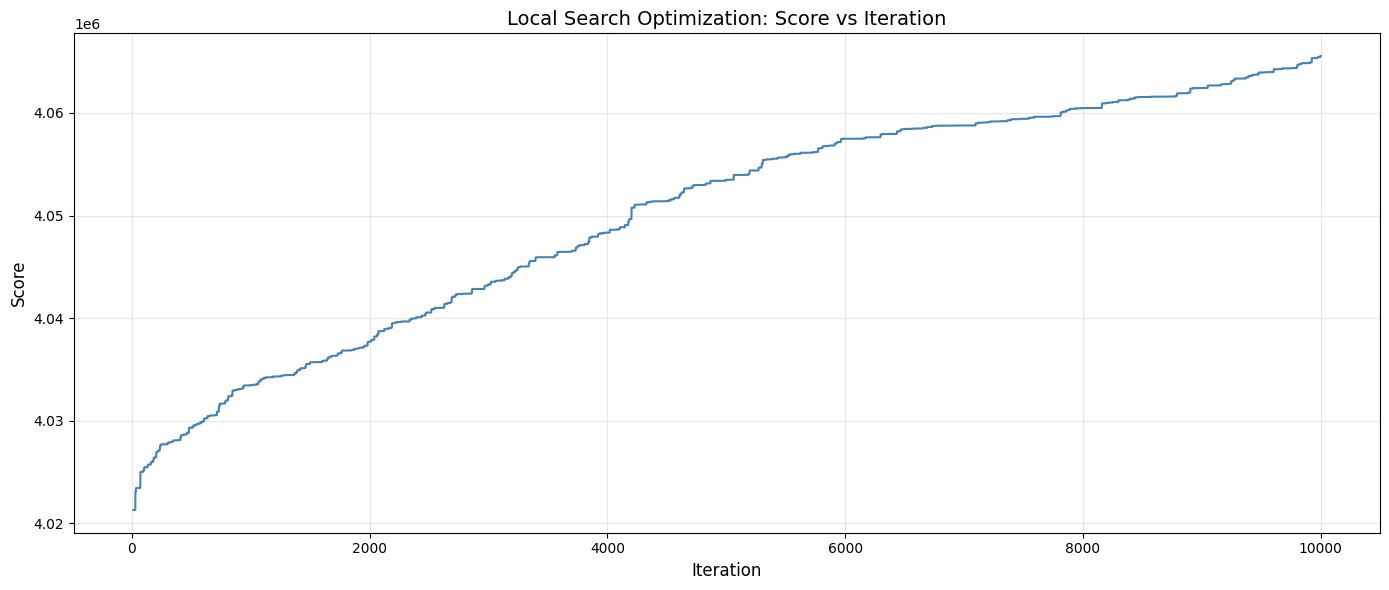

Plot saved as 'iterations_plot.png'
Total iterations tracked: 739
Final best score: 4065548


In [ ]:
import matplotlib.pyplot as plt
import re

# Read the file
with open('iterations.txt', 'r') as f:
    content = f.read()

# Parse iterations and scores
iterations = []
scores = []

# Extract all lines with iteration data
lines = content.strip().split('\n')

current_score = None
for line in lines:
    # Match pattern: [iter X] or [iter X] Improved: YYYY
    match = re.search(r'\[iter (\d+)\]', line)
    if match:
        iter_num = int(match.group(1))

        # Check if this line has a score (either "Improved:" or "current best:")
        score_match = re.search(r': (\d+)$', line)
        if score_match:
            current_score = int(score_match.group(1))

        iterations.append(iter_num)
        scores.append(current_score)

# Fill in missing iterations (0 to 10000)
# Create complete arrays from iter 0 to 10000
all_iters = list(range(10001))  # 0 to 10000
all_scores = []

score_dict = dict(zip(iterations, scores))
current_best = None

for i in range(10001):
    if i in score_dict and score_dict[i] is not None:
        current_best = score_dict[i]
    all_scores.append(current_best)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(all_iters, all_scores, linewidth=1.5, color='steelblue')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Local Search Optimization: Score vs Iteration', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('iterations_plot.png', dpi=300)
plt.show()

print(f"Plot saved as 'iterations_plot.png'")
print(f"Total iterations tracked: {len(iterations)}")
print(f"Final best score: {all_scores[-1]}")

# Model 4

In [ ]:
import sys
from collections import defaultdict, Counter, deque

# --- CONFIGURATION ---
INPUT_FILENAME = 'hashcode.in.txt'
OUTPUT_FILENAME = 'submission_optimized.out'
PRINT_INTERVAL = 500

def solve_time_ordered_greedy():
    # ==========================================
    # 1. PARSE INPUT
    # ==========================================
    print(f"Reading {INPUT_FILENAME}...")
    try:
        with open(INPUT_FILENAME, 'r') as f:
            lines = f.read().splitlines()
    except FileNotFoundError:
        print("File not found.")
        return

    iterator = iter(lines)
    D, I, S, V, F = map(int, next(iterator).split())

    street_map = {}  # name -> (end_node, length)
    intersection_in = defaultdict(list)

    for _ in range(S):
        parts = next(iterator).split()
        name = parts[2]
        E = int(parts[1])
        L = int(parts[3])
        street_map[name] = (E, L)
        intersection_in[E].append(name)

    car_paths = []
    for _ in range(V):
        parts = next(iterator).split()
        car_paths.append(parts[1:])

    # ==========================================
    # 2. ADVANCED ANALYSIS
    # ==========================================
    print("Analyzing traffic flow & timing...")

    street_importance = Counter()
    street_arrival_times = defaultdict(list)

    # We simulate "free flow" travel to guess when cars arrive at each street
    # This helps us order the green lights correctly (First-Arrive, First-Serve)

    for path in car_paths:
        # 1. Filter Impossible Paths (though you said all finish, let's be safe)
        min_travel = sum(street_map[s][1] for s in path)
        if min_travel > D: continue

        # 2. Calculate Weight (High Value for Short Paths)
        # The "magic formula" that worked well previously
        weight = 1 + (10000 / (min_travel + 1))

        current_time = 0
        for street in path:
            street_importance[street] += weight

            # Record expected arrival time at the END of this street
            # (Assuming no wait, which is our goal)
            travel_time = street_map[street][1]
            current_time += travel_time
            street_arrival_times[street].append(current_time)

    # ==========================================
    # 3. BUILD OPTIMIZED SCHEDULE
    # ==========================================
    print("Generating Time-Ordered Schedule...")

    intersection_schedules = {}

    for i_id in range(I):
        incoming = intersection_in[i_id]
        active = [s for s in incoming if street_importance[s] > 0]

        if not active:
            continue

        # --- STEP A: Determine Order ---
        # Sort streets by WHEN cars arrive.
        # If Street A has cars arriving at T=10, and Street B at T=50, A goes first.
        # We use the 10th percentile arrival time to capture the "leading edge" of the platoon.
        def get_earliness(street_name):
            times = street_arrival_times[street_name]
            if not times: return float('inf')
            times.sort()
            # Take the arrival time of the first few cars
            idx = min(len(times)-1, 0)
            return times[idx]

        active.sort(key=get_earliness)

        # --- STEP B: Determine Duration ---
        total_imp = sum(street_importance[s] for s in active)
        cycle = []

        for street in active:
            imp = street_importance[street]
            ratio = imp / total_imp

            # Keep cycles tight! Large cycles kill score.
            # Max duration 2s. Only 3s if it's an absolute highway.
            if ratio > 0.5:
                duration = 2
            else:
                duration = 1

            cycle.append((street, duration))

        intersection_schedules[i_id] = cycle

    # ==========================================
    # 4. SIMULATION (VALIDATION)
    # ==========================================
    print("\nRunning Simulation...")
    print("-" * 50)
    print(f"{'Time':<10} | {'Cars Finished':<15} | {'Score':<10}")
    print("-" * 50)

    # -- Sim State --
    queues = defaultdict(deque)
    car_props = []

    # Init cars
    for c_idx, path in enumerate(car_paths):
        start_street = path[0]
        queues[start_street].append(c_idx)
        car_props.append({
            'path_idx': 0,
            'arrival_time': 0,
            'state': 'queued'
        })

    # Init Lights
    int_states = {}
    for i_id, sched in intersection_schedules.items():
        if sched:
            int_states[i_id] = {'idx': 0, 't_rem': sched[0][1]}

    finished_count = 0
    current_score = 0

    for t in range(D + 1):

        # -- Process Intersections --
        for i_id, sched in intersection_schedules.items():
            if not sched: continue

            state = int_states[i_id]
            green_street_name, duration = sched[state['idx']]

            # Try to move ONE car
            street_q = queues[green_street_name]

            if street_q:
                c_idx = street_q[0]
                car = car_props[c_idx]

                # Check if physically arrived
                if car['arrival_time'] <= t:
                    street_q.popleft()

                    # Advance Car
                    p_idx = car['path_idx'] + 1
                    path = car_paths[c_idx]

                    if p_idx >= len(path):
                        # Finished
                        finished_count += 1
                        points = F + (D - t)
                        current_score += points
                        car['state'] = 'done'
                    else:
                        # Move to next street
                        next_s = path[p_idx]
                        travel = street_map[next_s][1]
                        car['path_idx'] = p_idx
                        car['arrival_time'] = t + travel
                        queues[next_s].append(c_idx)

            # -- Update Light Timer --
            state['t_rem'] -= 1
            if state['t_rem'] == 0:
                # Switch light
                state['idx'] = (state['idx'] + 1) % len(sched)
                state['t_rem'] = sched[state['idx']][1]

        # -- Logging --
        if t % PRINT_INTERVAL == 0 or t == D:
            print(f"{t:<10} | {finished_count:<15} | {current_score:<10}")

    print("-" * 50)
    print(f"Total Score: {current_score}")

    # ==========================================
    # 5. WRITE OUTPUT
    # ==========================================
    with open(OUTPUT_FILENAME, 'w') as f:
        f.write(f"{len(intersection_schedules)}\n")
        for i_id, sched in intersection_schedules.items():
            f.write(f"{i_id}\n")
            f.write(f"{len(sched)}\n")
            for name, duration in sched:
                f.write(f"{name} {duration}\n")

    print(f"File saved: {OUTPUT_FILENAME}")

if __name__ == "__main__":
    solve_time_ordered_greedy()

## Real-City Case-Study (Bengaluru)

In [ ]:
import pandas as pd
df_map = pd.read_csv("Bengaluru_Edgelist.csv")
df_map.head()

,XCoord,YCoord,START_NODE,END_NODE,EDGE,LENGTH
0,860107.596026,1.302889e+06,1,2,1,467.211740
1,860390.919234,1.303260e+06,2,1,1,467.211740
2,860390.919234,1.303260e+06,2,4,2,318.243502
3,860390.919234,1.303260e+06,2,8,4,317.369626
4,860702.591642,1.303317e+06,4,2,2,318.243502


In [ ]:
# ...existing code...
import networkx as nx
import matplotlib.pyplot as plt

# column names in your file
src_col = 'START_NODE'
tgt_col = 'END_NODE'
xcol = 'XCoord'
ycol = 'YCoord'

# drop rows with missing endpoints
edges_df = df_map.dropna(subset=[src_col, tgt_col]).copy()

# include all other columns as edge attributes
edge_attr = [c for c in edges_df.columns if c not in [src_col, tgt_col]]
G = nx.from_pandas_edgelist(edges_df, source=src_col, target=tgt_col, edge_attr=edge_attr, create_using=nx.DiGraph())

print("Graph built: nodes =", G.number_of_nodes(), "edges =", G.number_of_edges())

# build node positions from XCoord/YCoord (mean of incident edge coords)
pos = {}
if xcol in edges_df.columns and ycol in edges_df.columns:
    all_nodes = set(edges_df[src_col]).union(set(edges_df[tgt_col]))
    for n in all_nodes:
        rows = edges_df[(edges_df[src_col] == n) | (edges_df[tgt_col] == n)]
        if not rows.empty:
            pos[n] = (rows[xcol].mean(), rows[ycol].mean())

# fill missing positions with spring layout
if len(pos) < G.number_of_nodes():
    pos_spring = nx.spring_layout(G, seed=42)
    for n in G.nodes():
        if n not in pos:
            pos[n] = pos_spring[n]


Graph built: nodes = 151947 edges = 398956


Saved node cluster assignments to node_clusters_k5.csv (K=5)


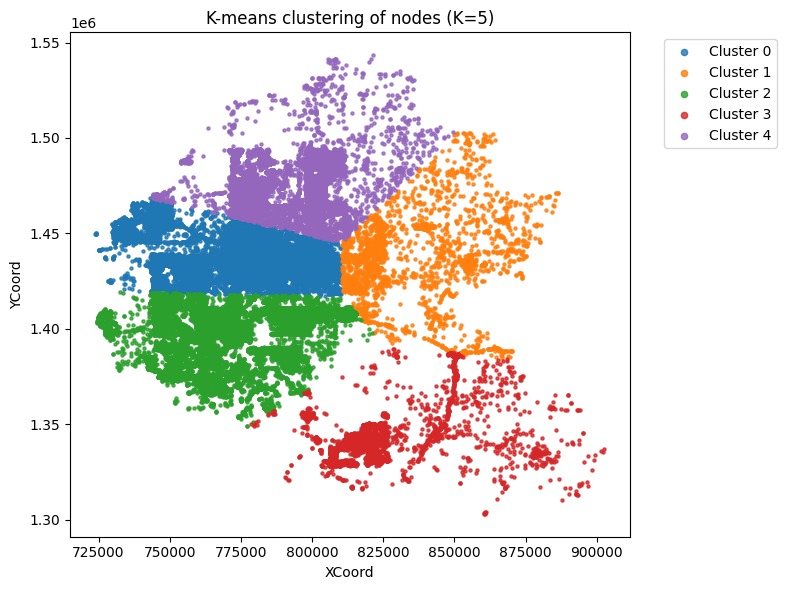

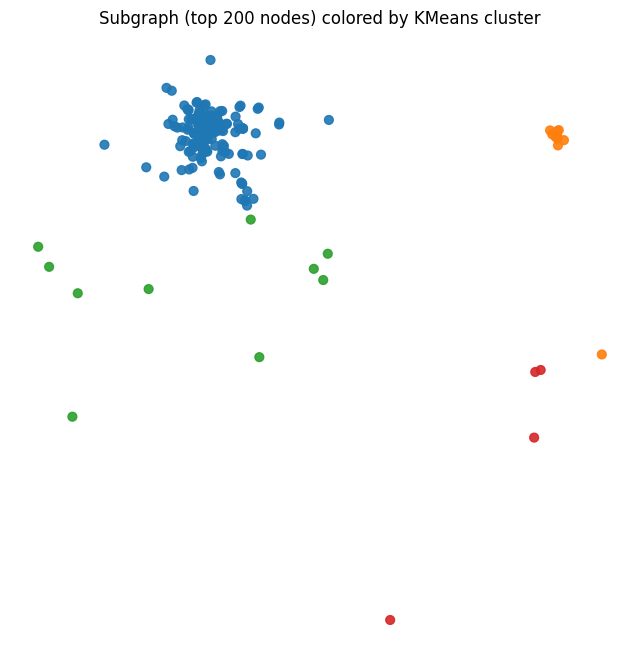

Saved graph to Bengaluru_Edgelist_graph_with_clusters_k5.gexf


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Parameters
K = 5
RANDOM_STATE = 42

# Build node coordinate table from edges_df (mean of incident edge coords)
src_col = 'START_NODE'
tgt_col = 'END_NODE'
xcol = 'XCoord'
ycol = 'YCoord'

df_src = edges_df[[src_col, xcol, ycol]].rename(columns={src_col: 'node'})
df_tgt = edges_df[[tgt_col, xcol, ycol]].rename(columns={tgt_col: 'node'})
node_coords = pd.concat([df_src, df_tgt], ignore_index=True)
node_coords = node_coords.groupby('node', as_index=False).agg({xcol: 'mean', ycol: 'mean'})
node_coords = node_coords.dropna(subset=[xcol, ycol]).reset_index(drop=True)

# Run KMeans
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
coords = node_coords[[xcol, ycol]].to_numpy()
node_coords['cluster'] = km.fit_predict(coords)

# Attach cluster label to NetworkX graph nodes
for _, r in node_coords.iterrows():
    n = r['node']
    if n in G:
        G.nodes[n]['x'] = float(r[xcol])
        G.nodes[n]['y'] = float(r[ycol])
        G.nodes[n]['cluster'] = int(r['cluster'])

# Save node cluster assignments
node_coords.to_csv('node_clusters_k5.csv', index=False)
print(f"Saved node cluster assignments to node_clusters_k5.csv (K={K})")

# Plot clusters (scatter) and optionally overlay small subgraph
plt.figure(figsize=(8,6))
cmap = plt.get_cmap('tab10')
for k in range(K):
    subset = node_coords[node_coords['cluster'] == k]
    plt.scatter(subset[xcol], subset[ycol], s=5, color=cmap(k % 5), label=f'Cluster {k}', alpha=0.8)

plt.title(f'K-means clustering of nodes (K={K})')
plt.xlabel(xcol); plt.ylabel(ycol)
plt.legend(markerscale=2, bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Optional: draw a small subgraph colored by cluster (top nodes by degree)
TOP_N = 200
top_nodes = [n for n,_ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]]
H = G.subgraph(top_nodes).copy()
# build positions for H from node attributes (fall back to spring)
pos_H = {}
for n in H.nodes():
    x = G.nodes[n].get('x'); y = G.nodes[n].get('y')
    if x is not None and y is not None:
        pos_H[n] = (x, y)
pos_missing = [n for n in H.nodes() if n not in pos_H]
if pos_missing:
    pos_spring = nx.spring_layout(H, seed=RANDOM_STATE)
    for n in pos_missing:
        pos_H[n] = pos_spring[n]

plt.figure(figsize=(8,8))
# draw nodes colored by cluster
node_colors = []
for n in H.nodes():
    cl = G.nodes[n].get('cluster', -1)
    node_colors.append(cmap(cl % 10) if cl >= 0 else 'gray')

nx.draw_networkx_nodes(H, pos_H, node_size=40, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(H, pos_H, alpha=0.3, width=0.6, arrows=False)
plt.title(f'Subgraph (top {TOP_N} nodes) colored by KMeans cluster')
plt.axis('off')
plt.show()

# Save updated graph with cluster attribute
nx.write_gexf(G, "Bengaluru_Edgelist_graph_with_clusters_k5.gexf")
print("Saved graph to Bengaluru_Edgelist_graph_with_clusters_k5.gexf")


In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ============================================================
# 1) Data structures
# ============================================================

class Street:
    def __init__(self, unique_id, start, end, name, length_m, speed_mps):
        self.unique_id = unique_id
        self.start = start
        self.end = end
        self.name = name
        self.length_m = length_m
        # integer travel time (ceil)
        self.travel_time = int(np.ceil(length_m / speed_mps))


class Car:
    def __init__(self, unique_id, streets):
        self.unique_id = unique_id
        self.streets = streets  # list[Street]

    def time_need_to_drive(self):
        # HashCode style: sum AFTER first intersection
        if len(self.streets) <= 1:
            return 0
        return sum(st.travel_time for st in self.streets[1:])


class Intersection:
    def __init__(self, idx):
        self.id = idx
        self.incoming = []  # list[Street]
        self.outgoing = []  # list[Street]


class Problem:
    def __init__(self, duration, bonus_per_car):
        self.duration = duration
        self.bonus_per_car = bonus_per_car
        self.intersections = []  # list[Intersection]
        self.streets = []        # list[Street]
        self.cars = []           # list[Car]


class GreenLightCycle:
    def __init__(self, street, duration):
        self.street = street
        self.duration = duration


class SolutionIntersection:
    def __init__(self, idx):
        self.id = idx
        self.green_cycles = []      # list[GreenLightCycle]


class Solution:
    def __init__(self, num_intersections):
        self.intersections = [SolutionIntersection(i) for i in range(num_intersections)]


class VisCarState:
    """
    State used in city-level sim with queues.
    """
    def __init__(self, car):
        self.car = car
        self.idx = 0                # index of last-completed street
        self.state = "queue"        # 'queue', 'moving', 'finished'
        self.time_on_edge = 0       # seconds on current moving edge
        self.moving_edge_idx = None # index of edge being travelled
        self.finish_time = None     # time when car finished

# ============================================================
# 2) Helper: build cluster subgraph + node positions
# ============================================================

def build_cluster_subgraph(edges_df,
                           node_coords,
                           cluster_id,
                           node_col="node",
                           cluster_col="cluster",
                           start_col="START_NODE",
                           end_col="END_NODE",
                           length_col="LENGTH",
                           xcol="XCoord",
                           ycol="YCoord"):
    """
    Filter edges + nodes for a given cluster and build:
      - df_cluster: edges fully inside that cluster
      - node_pos: dict original_node_id -> (x, y)
    Assumes:
      node_coords has columns [node_col, xcol, ycol, cluster_col]
      edges_df has columns [start_col, end_col, length_col, ...]
    """
    # nodes belonging to this cluster
    cluster_nodes = set(
        node_coords.loc[node_coords[cluster_col] == cluster_id, node_col].unique()
    )

    # keep only edges where BOTH ends are in the cluster
    mask = (
        edges_df[start_col].isin(cluster_nodes)
        & edges_df[end_col].isin(cluster_nodes)
    )
    df_cluster = edges_df.loc[mask, [start_col, end_col, length_col]].copy()
    df_cluster = df_cluster.rename(
        columns={start_col: "START_NODE", end_col: "END_NODE", length_col: "LENGTH"}
    )

    # node positions for nodes in this cluster
    sub_nodes = node_coords[node_coords[cluster_col] == cluster_id]
    node_pos = {
        int(row[node_col]): (float(row[xcol]), float(row[ycol]))
        for _, row in sub_nodes.iterrows()
    }

    return df_cluster, node_pos

# ============================================================
# 3) Build Problem from df_cluster
# ============================================================

def build_problem_from_df(df_cluster,
                          sim_duration,
                          bonus_per_car,
                          speed_mps):
    """
    df_cluster must have columns:
      ['START_NODE', 'END_NODE', 'LENGTH']
    """
    problem = Problem(sim_duration, bonus_per_car)

    # Map original node IDs -> intersection indices [0..N-1]
    all_nodes = sorted(set(df_cluster['START_NODE']).union(df_cluster['END_NODE']))
    node_id_to_index = {node_id: idx for idx, node_id in enumerate(all_nodes)}
    num_inters = len(all_nodes)

    problem.intersections = [Intersection(i) for i in range(num_inters)]

    streets = []
    adjacency = defaultdict(list)  # start_idx -> list[Street]

    for uid, row in enumerate(df_cluster.itertuples()):
        start_node = row.START_NODE
        end_node = row.END_NODE
        length_m = float(row.LENGTH)

        start_idx = node_id_to_index[start_node]
        end_idx = node_id_to_index[end_node]

        st = Street(
            unique_id=uid,
            start=start_idx,
            end=end_idx,
            name=f"e{uid}",
            length_m=length_m,
            speed_mps=speed_mps,
        )
        streets.append(st)
        adjacency[start_idx].append(st)

    problem.streets = streets

    # fill incoming/outgoing
    for st in streets:
        problem.intersections[st.start].outgoing.append(st)
        problem.intersections[st.end].incoming.append(st)

    return problem, adjacency, node_id_to_index

# ============================================================
# 4) Random car routes (simple paths)
# ============================================================

def generate_random_car_paths(problem,
                              adjacency,
                              num_cars=1000,
                              nodes_per_path=30,
                              random_seed=42):
    rng = np.random.default_rng(random_seed)
    cars = []

    intersection_ids = list(range(len(problem.intersections)))
    attempts = 0
    max_attempts = num_cars * 10

    while len(cars) < num_cars and attempts < max_attempts:
        attempts += 1

        n_nodes = max(2, int(nodes_per_path))  # enforce ≥2
        start_inter = rng.choice(intersection_ids)

        path_streets = []
        current = start_inter
        visited_nodes = {current}

        for _ in range(n_nodes - 1):
            outgoing_all = adjacency.get(current, [])
            # only move to unvisited nodes -> simple path
            outgoing = [st for st in outgoing_all if st.end not in visited_nodes]
            if not outgoing:
                break
            st = rng.choice(outgoing)
            path_streets.append(st)
            current = st.end
            visited_nodes.add(current)

        if len(path_streets) < 2:
            continue

        cars.append(Car(unique_id=len(cars), streets=path_streets))

    problem.cars = cars
    return problem

# ============================================================
# 5) Model 3: weighted fixed-time schedule
# ============================================================

def build_weighted_solution(problem):
    """
    Model 3:
    - Count how many 'finishable' cars use each incoming street.
    - Allocate a short cycle at each intersection, with green
      durations proportional to that usage.
    """
    D = problem.duration
    solution = Solution(num_intersections=len(problem.intersections))

    street_weight = defaultdict(float)

    # 1) weight streets by cars that CAN finish within D
    for car in problem.cars:
        total_time = car.time_need_to_drive()
        if total_time > D:
            continue
        w = 1.0  # or w = 1 + (D - total_time)/D
        for i in range(len(car.streets) - 1):  # ignore final link
            st = car.streets[i]
            street_weight[st.unique_id] += w

    # 2) distribute green within each intersection
    for inter in problem.intersections:
        si = solution.intersections[inter.id]
        incoming = inter.incoming
        if not incoming:
            continue

        weights = [street_weight[st.unique_id] for st in incoming]
        total_w = sum(weights)

        if total_w == 0:
            # no info -> give each 1 second
            for st in incoming:
                si.green_cycles.append(GreenLightCycle(street=st, duration=1))
            continue

        TOTAL_CYCLE = min(10, max(3, len(incoming)))  # 3–10 seconds

        durations = []
        for w in weights:
            dur = max(1, int(round(TOTAL_CYCLE * w / total_w)))
            durations.append(dur)

        extra = sum(durations) - TOTAL_CYCLE
        while extra > 0 and any(d > 1 for d in durations):
            for idx, d in enumerate(durations):
                if extra == 0:
                    break
                if d > 1:
                    durations[idx] -= 1
                    extra -= 1

        # order streets by weight (descending)
        order = sorted(range(len(incoming)), key=lambda idx: -weights[idx])
        for idx in order:
            st = incoming[idx]
            dur = durations[idx]
            si.green_cycles.append(GreenLightCycle(street=st, duration=dur))

    return solution


def solution_to_light_schedule(solution):
    """
    Convert Solution -> {intersection_id: [street_id, street_id, ...]} cycle.
    """
    schedule = {}
    for si in solution.intersections:
        arr = []
        for cyc in si.green_cycles:
            arr.extend([cyc.street.unique_id] * cyc.duration)
        if arr:
            schedule[si.id] = arr
    return schedule

# ============================================================
# 6) City simulation with metrics
# ============================================================

def simulate_city_with_metrics(problem,
                               light_schedule,
                               index_to_xy=None,
                               record_snapshots=False,
                               max_time=None):
    """
    Discrete-time sim with FCFS queues.
    Returns (snapshots, metrics).
    """
    D = problem.duration
    T = D if max_time is None else min(D, max_time)
    bonus = problem.bonus_per_car

    # init car states + queues
    car_states = []
    queues = defaultdict(deque)  # street_id -> deque of car_ids

    for car_id, car in enumerate(problem.cars):
        cs = VisCarState(car)
        first_street = car.streets[0]
        queues[first_street.unique_id].append(car_id)
        car_states.append(cs)

    # metrics
    street_wait_time = defaultdict(int)
    street_max_queue = defaultdict(int)
    inter_total_green = defaultdict(int)
    inter_wasted_green = defaultdict(int)

    snapshots = [] if record_snapshots and index_to_xy is not None else None

    for t in range(T + 1):
        # 1) move cars that are on an edge
        for car_id, cs in enumerate(car_states):
            if cs.state != "moving":
                continue

            cs.time_on_edge += 1
            edge = cs.car.streets[cs.moving_edge_idx]

            if cs.time_on_edge >= edge.travel_time:
                cs.idx = cs.moving_edge_idx
                cs.moving_edge_idx = None
                cs.time_on_edge = 0

                if cs.idx == len(cs.car.streets) - 1:
                    cs.state = "finished"
                    cs.finish_time = t
                else:
                    cs.state = "queue"
                    cur_street = cs.car.streets[cs.idx]
                    queues[cur_street.unique_id].append(car_id)

        # 2) for each intersection, serve at most 1 car
        for inter in problem.intersections:
            inter_id = inter.id
            if inter_id not in light_schedule:
                continue
            cycle = light_schedule[inter_id]
            if not cycle:
                continue

            green_street_id = cycle[t % len(cycle)]
            inter_total_green[inter_id] += 1

            if queues[green_street_id]:
                car_id = queues[green_street_id].popleft()
                cs = car_states[car_id]
                if cs.state != "queue":
                    continue
                if cs.idx >= len(cs.car.streets) - 1:
                    continue

                cs.state = "moving"
                cs.moving_edge_idx = cs.idx + 1
                cs.time_on_edge = 0
            else:
                inter_wasted_green[inter_id] += 1

        # 3) queue metrics
        for st_id, q in queues.items():
            q_len = len(q)
            street_wait_time[st_id] += q_len
            if q_len > street_max_queue[st_id]:
                street_max_queue[st_id] = q_len

        # 4) optional snapshots for animation
        if snapshots is not None:
            xs, ys = [], []
            for cs in car_states:
                if cs.state == "finished":
                    last_st = cs.car.streets[-1]
                    x, y = index_to_xy[last_st.end]
                    xs.append(x); ys.append(y)
                elif cs.state == "queue":
                    st = cs.car.streets[cs.idx]
                    x, y = index_to_xy[st.end]
                    xs.append(x); ys.append(y)
                elif cs.state == "moving":
                    edge = cs.car.streets[cs.moving_edge_idx]
                    x0, y0 = index_to_xy[edge.start]
                    x1, y1 = index_to_xy[edge.end]
                    travel_time = max(1, edge.travel_time)
                    frac = cs.time_on_edge / travel_time
                    x = x0 + frac * (x1 - x0)
                    y = y0 + frac * (y1 - y0)
                    xs.append(x); ys.append(y)
            snapshots.append((np.array(xs), np.array(ys)))

    # final scoring
    finished_cars = 0
    total_time_saved = 0
    total_score = 0

    for cs in car_states:
        if cs.finish_time is not None and cs.finish_time <= D:
            finished_cars += 1
            time_saved = D - cs.finish_time
            total_time_saved += time_saved
            total_score += bonus + time_saved

    metrics = {
        "score": total_score,
        "finished_cars": finished_cars,
        "total_time_saved": total_time_saved,
        "street_wait_time": street_wait_time,
        "street_max_queue": street_max_queue,
        "intersection_total_green": inter_total_green,
        "intersection_wasted_green": inter_wasted_green,
    }

    return snapshots, metrics

# ============================================================
# 7) Heatmap + hotspot summaries
# ============================================================

def plot_street_congestion_heatmap(problem,
                                   metrics,
                                   index_to_xy,
                                   figsize=(8, 8),
                                   cmap_name="Reds",
                                   title="Street-level congestion heatmap"):
    street_wait = metrics["street_wait_time"]
    scores = np.array(
        [street_wait.get(st.unique_id, 0) for st in problem.streets],
        dtype=float
    )
    max_score = scores.max() if len(scores) > 0 else 0.0
    if max_score == 0:
        max_score = 1.0

    norm = Normalize(vmin=0, vmax=max_score)
    cmap = cm.get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    for st, score in zip(problem.streets, scores):
        x0, y0 = index_to_xy[st.start]
        x1, y1 = index_to_xy[st.end]
        c = cmap(norm(score))
        lw = 0.3 + 3.0 * (score / max_score)
        ax.plot([x0, x1], [y0, y1],
                color=c,
                linewidth=lw,
                alpha=0.2 + 0.6 * (score / max_score))

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)

    all_x = [xy[0] for xy in index_to_xy.values()]
    all_y = [xy[1] for xy in index_to_xy.values()]
    ax.set_xlim(min(all_x) - 50, max(all_x) + 50)
    ax.set_ylim(min(all_y) - 50, max(all_y) + 50)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Total waiting time (car-seconds)")

    plt.show()


def summarize_street_hotspots(problem, metrics, top_k=15):
    street_wait = metrics["street_wait_time"]
    street_maxq = metrics["street_max_queue"]

    rows = []
    for st in problem.streets:
        rows.append({
            "street_id": st.unique_id,
            "start_inter": st.start,
            "end_inter": st.end,
            "total_wait_time": street_wait.get(st.unique_id, 0),
            "max_queue": street_maxq.get(st.unique_id, 0),
        })
    df = pd.DataFrame(rows)
    df = df.sort_values("total_wait_time", ascending=False).head(top_k)
    return df.reset_index(drop=True)


def summarize_intersection_hotspots(metrics, top_k=10):
    tot_green = metrics["intersection_total_green"]
    wasted = metrics["intersection_wasted_green"]

    rows = []
    for i in tot_green.keys():
        g = tot_green[i]
        w = wasted.get(i, 0)
        wasted_ratio = w / g if g > 0 else 0.0
        rows.append({
            "intersection_id": i,
            "total_green": g,
            "wasted_green": w,
            "wasted_ratio": wasted_ratio,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values("wasted_ratio", ascending=False).head(top_k)
    return df.reset_index(drop=True)

# ============================================================
# 8) MAIN WRAPPER: run everything for a cluster
# ============================================================

def run_cluster_simulation(
    edges_df,
    node_coords,
    cluster_id=2,
    speed_mps=15.0,
    sim_duration=3600,
    bonus_per_car=1000,
    num_cars=20000,
    nodes_per_path=30,
    random_seed=42,
    top_k_streets=15,
    top_k_intersections=10,
    make_heatmap=True,
    heatmap_cmap="Reds",
    record_snapshots=True,
):
    """
    One-shot pipeline for a chosen cluster:

      1) Filter network to that cluster (nodes + edges)
      2) Build Problem object
      3) Generate random car routes (simple paths)
      4) Build Model 3 weighted signal schedule
      5) Simulate city, compute metrics
      6) Plot congestion heatmap (optional)
      7) Return metrics + hotspot tables

    Assumes:
      - edges_df has columns: START_NODE, END_NODE, LENGTH
      - node_coords has: node, XCoord, YCoord, cluster
    """
    # 1) cluster subgraph
    df_cluster, node_pos = build_cluster_subgraph(
        edges_df,
        node_coords,
        cluster_id=cluster_id,
        node_col="node",
        cluster_col="cluster",
        start_col="START_NODE",
        end_col="END_NODE",
        length_col="LENGTH",
        xcol="XCoord",
        ycol="YCoord",
    )

    print(f"[Cluster {cluster_id}] Edges: {len(df_cluster)}, Nodes: {len(node_pos)}")

    # 2) build Problem
    problem, adjacency, node_id_to_index = build_problem_from_df(
        df_cluster,
        sim_duration,
        bonus_per_car,
        speed_mps,
    )

    # map intersection index -> (x, y)
    index_to_xy = {
        idx: node_pos[node_id]
        for node_id, idx in node_id_to_index.items()
        if node_id in node_pos
    }

    # 3) random car routes
    problem = generate_random_car_paths(
        problem,
        adjacency,
        num_cars=num_cars,
        nodes_per_path=nodes_per_path,
        random_seed=random_seed,
    )

    print(f"[Cluster {cluster_id}] Cars generated: {len(problem.cars)}")

    # 4) Model 3 schedule
    solution = build_weighted_solution(problem)
    schedule = solution_to_light_schedule(solution)

    # 5) simulate
    snapshots, metrics = simulate_city_with_metrics(
        problem,
        schedule,
        index_to_xy=index_to_xy,
        record_snapshots=record_snapshots,      # set True if you want animation later
        max_time=sim_duration,
    )

    finished = metrics["finished_cars"]
    total = len(problem.cars)
    avg_save = (
        metrics["total_time_saved"] / finished if finished > 0 else 0.0
    )

    print(f"Model 3 score: {metrics['score']}")
    print(f"Cars finished within {sim_duration}s: {finished} / {total}")
    print(f"Avg time saved per finished car: {avg_save:.1f} s")

    # 6) heatmap (optional)
    if make_heatmap:
        plot_street_congestion_heatmap(
            problem,
            metrics,
            index_to_xy,
            title=f"Cluster {cluster_id} – Model 3 congestion heatmap",
            cmap_name=heatmap_cmap,
        )

    # 7) hotspot tables
    street_hotspots = summarize_street_hotspots(
        problem, metrics, top_k=top_k_streets
    )
    inter_hotspots = summarize_intersection_hotspots(
        metrics, top_k=top_k_intersections
    )

    results = {
        "cluster_id": cluster_id,
        "problem": problem,
        "solution": solution,
        "schedule": schedule,
        "metrics": metrics,
        "street_hotspots": street_hotspots,
        "intersection_hotspots": inter_hotspots,
        "index_to_xy": index_to_xy,
        "snapshots": snapshots,  # None unless you switch record_snapshots=True
    }

    return results

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt

def animate_cluster_traffic(results,
                            frame_step=100,
                            interval=500,
                            figsize=(8, 8),
                            title_prefix="Traffic simulation"):
    """
    Build a Matplotlib animation for a given cluster's simulation results.

    Parameters
    ----------
    results : dict
        Output from run_cluster_simulation(...) containing at least:
        - "problem": Problem object
        - "index_to_xy": dict[int -> (x,y)]
        - "snapshots": list of (xs, ys) arrays, one per second
    frame_step : int
        Show frames at t = 0, frame_step, 2*frame_step, ... (e.g. 100 s).
    interval : int
        Delay between frames in milliseconds for the animation.
    figsize : tuple
        Figure size for the plot.
    title_prefix : str
        Prefix string for the plot title.

    Returns
    -------
    HTML
        An HTML object you can display in a Jupyter notebook.
    """
    problem = results["problem"]
    index_to_xy = results["index_to_xy"]
    snapshots = results["snapshots"]

    if snapshots is None or len(snapshots) == 0:
        raise ValueError(
            "No snapshots found. "
            "Re-run run_cluster_simulation with record_snapshots=True."
        )

    # Build road segments
    road_segments = []
    for st in problem.streets:
        x0, y0 = index_to_xy[st.start]
        x1, y1 = index_to_xy[st.end]
        road_segments.append(((x0, x1), (y0, y1)))

    # Figure + static background
    fig, ax = plt.subplots(figsize=figsize)
    for xs, ys in road_segments:
        ax.plot(xs, ys, linewidth=0.5, alpha=0.3)

    # Initial positions at t = 0
    xs0, ys0 = snapshots[0]
    scatter = ax.scatter(xs0, ys0, s=5)
    ax.set_aspect("equal", adjustable="box")

    # Axis limits from node coordinates
    all_x = [xy[0] for xy in index_to_xy.values()]
    all_y = [xy[1] for xy in index_to_xy.values()]
    ax.set_xlim(min(all_x) - 50, max(all_x) + 50)
    ax.set_ylim(min(all_y) - 50, max(all_y) + 50)

    # Decide which time steps to show
    max_t = min(problem.duration, len(snapshots) - 1)
    frame_times = list(range(0, max_t + 1, frame_step))

    def update(frame_idx):
        t = frame_times[frame_idx]
        xs, ys = snapshots[t]
        scatter.set_offsets(np.c_[xs, ys])
        ax.set_title(f"{title_prefix} (t = {t} s)")
        return scatter,

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_times),
        interval=interval,
        blit=True
    )

    return HTML(anim.to_jshtml())



In [ ]:
from IPython.display import display, HTML

def run_and_show_all_clusters(edges_df,
                              node_coords,
                              cluster_ids,
                              speed_mps=15.0,
                              sim_duration=3600,
                              bonus_per_car=1000,
                              num_cars=20000,
                              nodes_per_path=30,
                              random_seed=42,
                              top_k_streets=20,
                              top_k_intersections=15,
                              frame_step=100,
                              anim_interval=500):
    """
    Run the city-traffic simulation for a list of clusters and
    show metrics, congestion heatmap, and animation one after another.

    Parameters
    ----------
    cluster_ids : iterable of int
        e.g. range(0, 5)
    Other parameters: see your earlier run_cluster_simulation signature.
    """

    all_results = {}

    for k in cluster_ids:
        print("\n" + "=" * 60)
        print(f"Cluster {k}: simulation results")
        print("=" * 60)

        # --- 1) Run simulation for this cluster ---
        res = run_cluster_simulation(
            edges_df=edges_df,
            node_coords=node_coords,
            cluster_id=k,
            speed_mps=speed_mps,
            sim_duration=sim_duration,
            bonus_per_car=bonus_per_car,
            num_cars=num_cars,
            nodes_per_path=nodes_per_path,
            random_seed=random_seed,
            top_k_streets=top_k_streets,
            top_k_intersections=top_k_intersections,
            make_heatmap=False,      # we'll call heatmap function explicitly
            record_snapshots=True    # IMPORTANT: needed for animation
        )
        all_results[k] = res

        problem       = res["problem"]
        index_to_xy   = res["index_to_xy"]
        metrics       = res["metrics"]
        snapshots     = res["snapshots"]

        # --- 2) Print core metrics ---
        finished = metrics["finished_cars"]
        total_cars = len(problem.cars)
        print(f"Score: {metrics['score']}")
        print(f"Cars finished within {sim_duration} s: {finished} / {total_cars}")
        if finished > 0:
            avg_saved = metrics["total_time_saved"] / finished
        else:
            avg_saved = 0.0
        print(f"Total time saved: {metrics['total_time_saved']} s")
        print(f"Average time saved per finished car: {avg_saved:.2f} s")

        # --- 3) Show congestion heatmap for this cluster ---
        plot_street_congestion_heatmap(
            problem,
            metrics,
            index_to_xy,
            title=f"Cluster {k}: street-level congestion heatmap"
        )

        # --- 4) Show textual hotspot summaries ---
        print(f"\nTop {top_k_streets} congested streets (cluster {k}):")
        display(summarize_street_hotspots(problem, metrics, top_k=top_k_streets))

        # --- 5) Show animation for this cluster ---
        print(f"\nAnimation for cluster {k}:")
        anim_html = animate_cluster_traffic(
            res,
            frame_step=frame_step,           # e.g. 0,100,200,... seconds
            interval=anim_interval,          # ms between frames
            title_prefix=f"Cluster {k} traffic"
        )
        display(anim_html)

    return all_results


In [ ]:
all_results = run_and_show_all_clusters(
    edges_df=edges_df,
    node_coords=node_coords,
    cluster_ids=range(0, 5),   # clusters 0..4
    speed_mps=15.0,
    sim_duration=3600,
    bonus_per_car=1000,
    num_cars=20000,
    nodes_per_path=30,
    random_seed=42,
    top_k_streets=20,
    top_k_intersections=15,
    frame_step=100,            # show t=0,100,200,...,3600
    anim_interval=500          # 0.5s per frame
)
